In [27]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.show()
df=pd.read_csv('ab_data.csv')
display(df.head())

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [16]:

mismatch_trt=df[(df["group"]=="treatment")&(df["landing_page"]=="old_page")]
mismatch_cntl=df[(df["group"]=="control")&(df["landing_page"]=="new_page")]
mismatch_count=len(mismatch_trt)+len(mismatch_cntl)

print("Hatalı eşleşme:",mismatch_count)

df_clean = df[((df["group"]=="control")&(df["landing_page"]=="old_page")) | 
              ((df["group"]=="treatment")&(df['landing_page']=="new_page"))]

print("Temizlenmiş:", df_clean.shape[0])

df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')

Hatalı eşleşme: 3893
Temizlenmiş: 290585


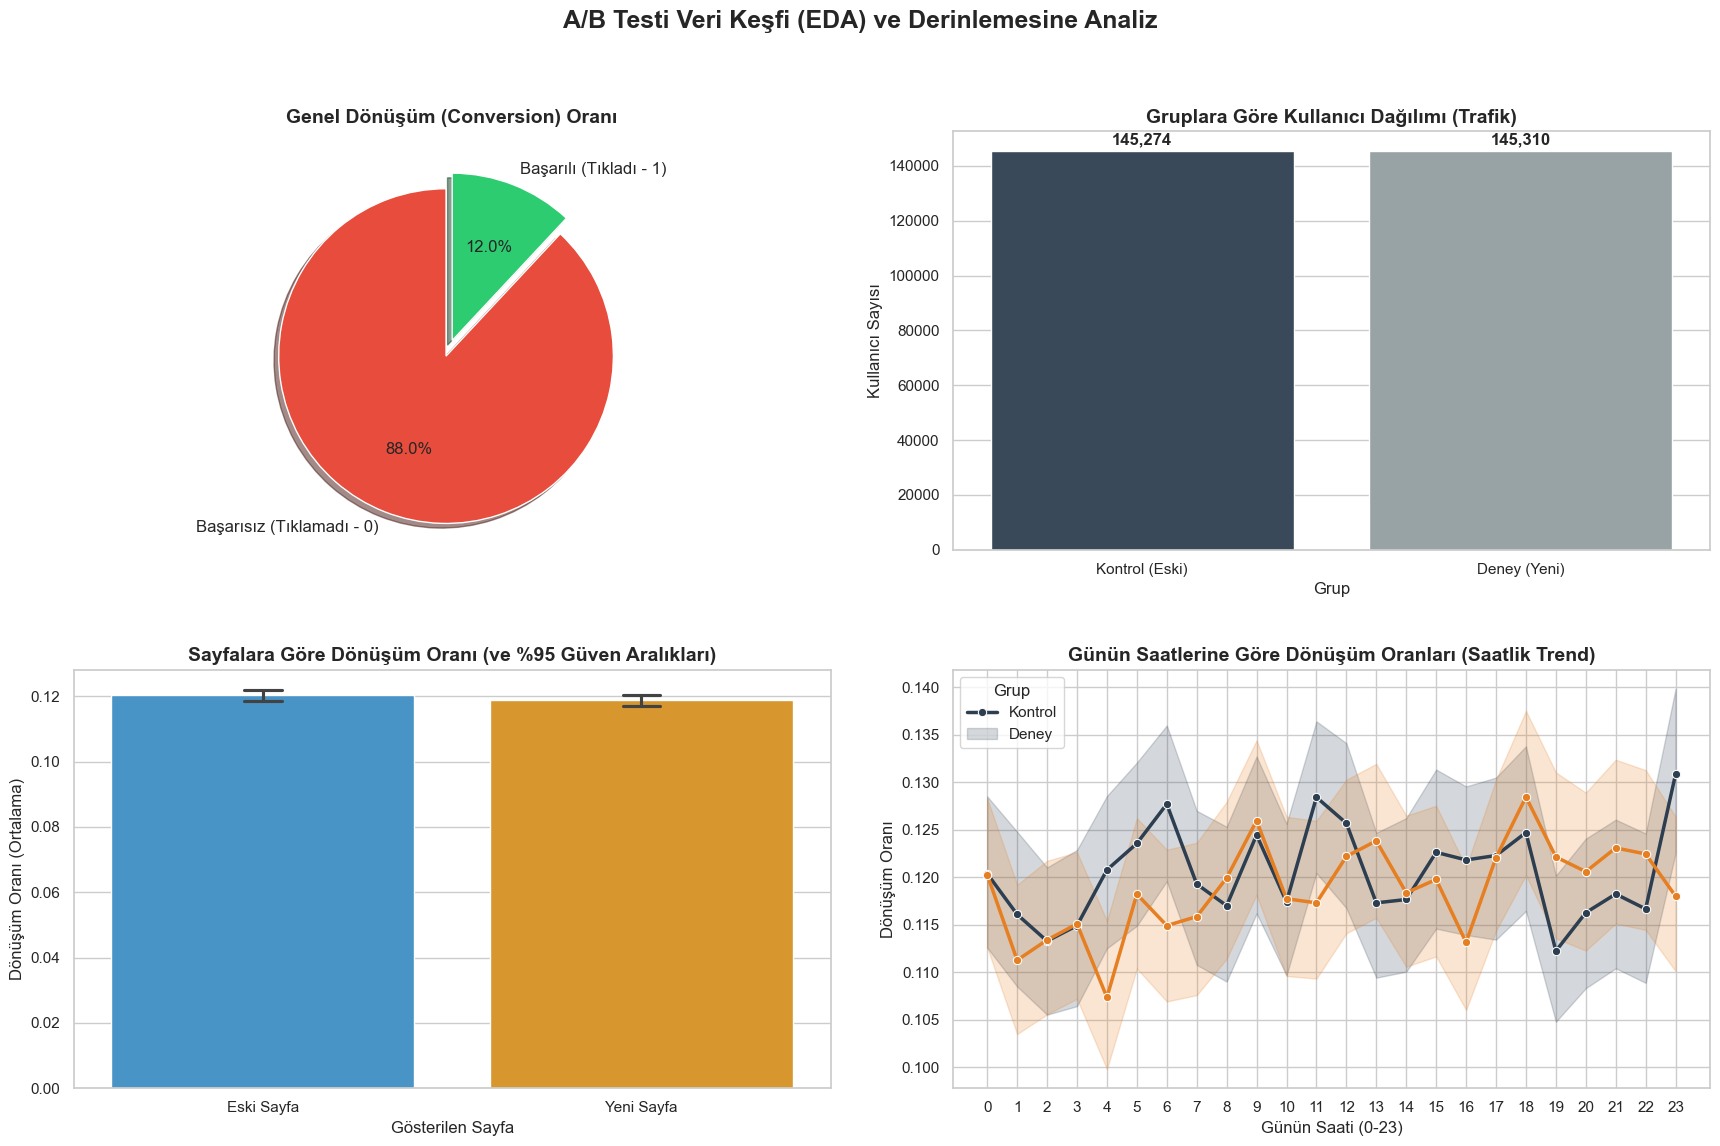

In [36]:


# Veri setindeki tarih/saat kolonunu Python'ın anlayacağı 'datetime' formatına çeviriyoruz
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

# Kendimizden kattığımız yaratıcı kısım: Saat bilgisini yeni bir kolon olarak çıkarıyoruz
df_clean['hour'] = df_clean['timestamp'].dt.hour

# Görselleştirme için genel ayarlar
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))
fig.suptitle('A/B Testi Veri Keşfi (EDA) ve Derinlemesine Analiz', fontsize=18, fontweight='bold', y=0.98)

# --- 1. GRAFİK: Genel Tıklanma / Tıklanmama Oranı (Pasta Grafiği) ---
ax1 = plt.subplot(2, 2, 1)
converted_counts = df_clean['converted'].value_counts()
ax1.pie(converted_counts, labels=['Başarısız (Tıklamadı - 0)', 'Başarılı (Tıkladı - 1)'], 
        autopct='%1.1f%%', startangle=90, colors=['#e74c3c', '#2ecc71'], 
        explode=(0.1, 0), shadow=True, textprops={'fontsize': 12})
ax1.set_title('Genel Dönüşüm (Conversion) Oranı', fontsize=14, fontweight='bold')


# --- 2. GRAFİK: Gruplara Göre Trafik Dağılımı (A/B Testi Eşit mi Bölünmüş?) ---
ax2 = plt.subplot(2, 2, 2)
sns.countplot(data=df_clean, x='group', palette=['#34495e', '#95a5a6'], ax=ax2, hue='group', legend=False)
ax2.set_title('Gruplara Göre Kullanıcı Dağılımı (Trafik)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Grup', fontsize=12)
ax2.set_ylabel('Kullanıcı Sayısı', fontsize=12)
ax2.set_xticks([0, 1]) # Önce koordinatları veriyoruz
ax2.set_xticklabels(['Kontrol (Eski)', 'Deney (Yeni)'])

# Barların üzerine sayıları yazdırma
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')


# --- 3. GRAFİK: Sayfalara Göre Dönüşüm Oranları (Hata Çubuklarıyla Birlikte) ---
ax3 = plt.subplot(2, 2, 3)
# errorbar=('ci', 95) ile %95 güven aralığını siyah küçük çubuklar olarak çizdiriyoruz
sns.barplot(data=df_clean, x='landing_page', y='converted', palette=['#3498db', '#f39c12'], 
            ax=ax3, errorbar=('ci', 95), capsize=0.1, hue='landing_page', legend=False)
ax3.set_title('Sayfalara Göre Dönüşüm Oranı (ve %95 Güven Aralıkları)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Gösterilen Sayfa', fontsize=12)
ax3.set_ylabel('Dönüşüm Oranı (Ortalama)', fontsize=12)
ax3.set_xticks([0, 1]) # Önce koordinatları veriyoruz
ax3.set_xticklabels(['Eski Sayfa', 'Yeni Sayfa']) # Sonra isimleri veriyoruz


# --- 4. GRAFİK: YARATICI DOKUNUŞ - Günün Saatlerine Göre Dönüşüm Performansı ---
ax4 = plt.subplot(2, 2, 4)
# Saatlere ve gruplara göre dönüşüm oranlarını hesaplayıp çizdiriyoruz
sns.lineplot(data=df_clean, x='hour', y='converted', hue='group', marker='o', 
             palette=['#2c3e50', '#e67e22'], linewidth=2.5, ax=ax4)
ax4.set_title('Günün Saatlerine Göre Dönüşüm Oranları (Saatlik Trend)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Günün Saati (0-23)', fontsize=12)
ax4.set_ylabel('Dönüşüm Oranı', fontsize=12)
ax4.set_xticks(range(0, 24))
ax4.legend(title='Grup', labels=['Kontrol', 'Deney'])

plt.tight_layout(pad=3.0)
plt.show()

,Toplam_Kullanici,Donusen_Kullanici,Donusum_Orani
group,,,
control,145274,17489,0.120386
treatment,145310,17264,0.118808


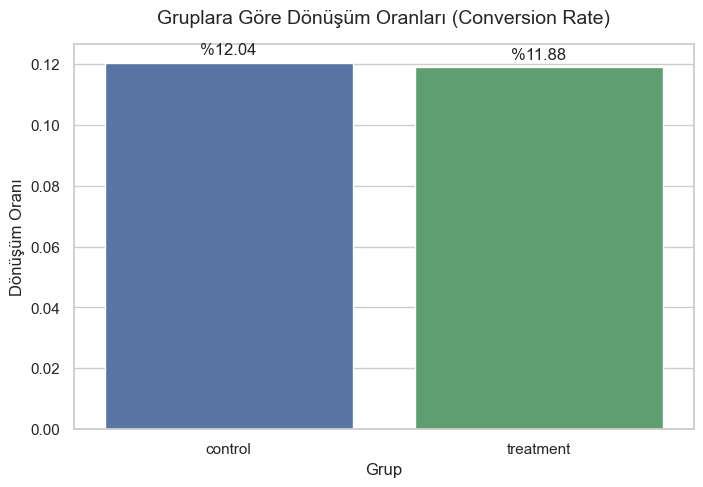

In [19]:
conversion_rates = df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
conversion_rates.columns = ['Toplam_Kullanici', 'Donusen_Kullanici', 'Donusum_Orani']
display(conversion_rates)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=conversion_rates.index, 
    y='Donusum_Orani', 
    data=conversion_rates, 
    palette=['#4C72B0', '#55A868'],
    hue=conversion_rates.index,
    legend=False             
)

plt.title('Gruplara Göre Dönüşüm Oranları (Conversion Rate)', fontsize=14, pad=15)
plt.xlabel('Grup', fontsize=12)
plt.ylabel('Dönüşüm Oranı', fontsize=12)

for p in ax.patches:
    ax.annotate(f'%{p.get_height()*100:.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

In [26]:
n_control = conversion_rates.loc['control', 'Toplam_Kullanici']
p_control = conversion_rates.loc['control', 'Donusum_Orani']

n_treatment = conversion_rates.loc['treatment', 'Toplam_Kullanici']
p_treatment = conversion_rates.loc['treatment', 'Donusum_Orani']

ex_control = n_control * p_control
var_control = n_control * p_control * (1 - p_control)

ex_treatment = n_treatment * p_treatment
var_treatment = n_treatment * p_treatment * (1 - p_treatment)

print("Kontrol Grubu -> Beklenen Değeri:", ex_control, "Varyansı:", var_control)
print("Deney Grubu  -> Beklenen Değeri:", ex_treatment,"Varyans:", var_treatment)

Kontrol Grubu -> Beklenen Değeri: 17489.0 Varyansı: 15383.563920591434
Deney Grubu  -> Beklenen Değeri: 17264.0 Varyans: 15212.897556947217


In [29]:
# Başarılı dönüşüm sayıları
x_control = conversion_rates.loc['control', 'Donusen_Kullanici']
x_treatment = conversion_rates.loc['treatment', 'Donusen_Kullanici']

# Havuzlanmış Oran (Pooled Proportion) hesaplaması
p_pooled = (x_control + x_treatment) / (n_control + n_treatment)

# Standart Hata (Standard Error) hesaplaması
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_treatment))

# Z-Skoru ve P-Değeri (P-Value) hesaplaması
z_score = (p_treatment - p_control) / se

# Çift yönlü test (two-tailed) olduğu için p-değerini 2 ile çarpıyoruz
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Z-Skoru: {z_score:.4f}")
print(f"P-Değeri: {p_value:.4f}")

# Hipotez Sonucu
alpha = 0.05
if p_value < alpha:
    print("\nSonuç: H0 Hipotezi REDDEDİLİR. İki sayfa arasında istatistiksel olarak anlamlı bir fark vardır.")
else:
    print("\nSonuç: H0 Hipotezi REDDEDİLEMEZ. İki sayfa arasındaki fark şans eseri olabilir, istatistiksel olarak anlamlı değildir.")

Z-Skoru: -1.3109
P-Değeri: 0.1899

Sonuç: H0 Hipotezi REDDEDİLEMEZ. İki sayfa arasındaki fark şans eseri olabilir, istatistiksel olarak anlamlı değildir.


In [31]:
# Güven düzeyi (Confidence Level) = %95 (Z_alpha/2 değeri yaklaşık 1.96'dır)
z_critical = stats.norm.ppf(0.975) 

# İki oran arasındaki fark (Point Estimate)
diff_proportions = p_treatment - p_control

# Güven Aralığı için Standart Hata (Standart Error for CI)
# Not: Hipotez testinde havuzlanmış (pooled) SE kullandık, Güven aralığında havuzlanmamış kullanırız.
se_ci = np.sqrt((p_control * (1 - p_control) / n_control) + 
                (p_treatment * (1 - p_treatment) / n_treatment))

# Güven Aralığının Alt ve Üst Sınırları (Margin of Error)
margin_of_error = z_critical * se_ci

ci_lower = diff_proportions - margin_of_error
ci_upper = diff_proportions + margin_of_error

print(f"İki sayfa arasındaki dönüşüm oranı farkı: {diff_proportions:.6f}")
print(f"%95 Güven Aralığı (CI): [{ci_lower:.6f},  {ci_upper:.6f}]")

# Yorumlama Mantığı
print("\n--- GÜVEN ARALIĞI YORUMU ---")
if ci_lower <= 0 <= ci_upper:
    print("Güven aralığı '0' (sıfır) değerini içermektedir.")
    print("Bu durum, iki sayfa arasında istatistiksel olarak anlamlı bir fark OLMADIĞINI bir kez daha kanıtlar.")
else:
    print("Güven aralığı '0' (sıfır) değerini içermemektedir.")
    print("İki sayfa arasında istatistiksel olarak anlamlı bir fark vardır.")

İki sayfa arasındaki dönüşüm oranı farkı: -0.001578
%95 Güven Aralığı (CI): [-0.003938,  0.000781]

--- GÜVEN ARALIĞI YORUMU ---
Güven aralığı '0' (sıfır) değerini içermektedir.
Bu durum, iki sayfa arasında istatistiksel olarak anlamlı bir fark OLMADIĞINI bir kez daha kanıtlar.


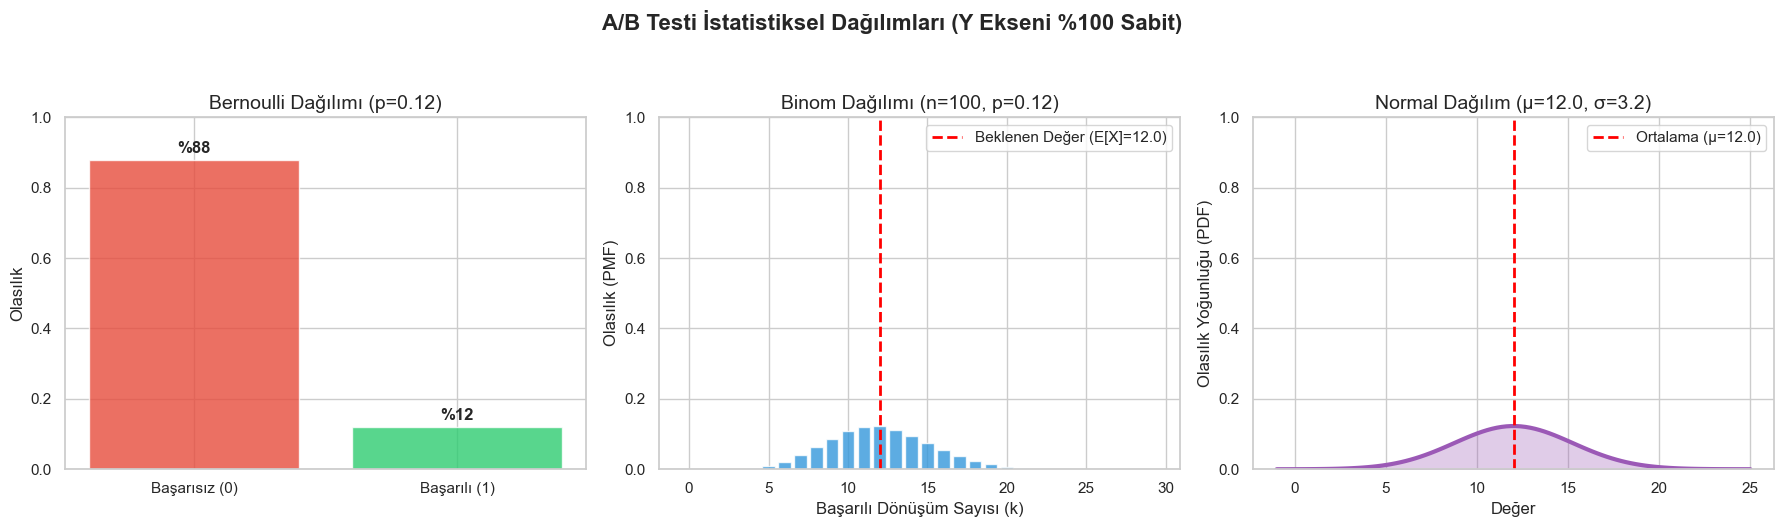

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('A/B Testi İstatistiksel Dağılımları (Y Ekseni %100 Sabit)', fontsize=16, fontweight='bold', y=1.05)

p = 0.12
n = 100

# --- 1. BERNOULLI DAĞILIMI ---
x_bernoulli = [0, 1]
y_bernoulli = [1 - p, p]
axes[0].bar(x_bernoulli, y_bernoulli, color=['#e74c3c', '#2ecc71'], alpha=0.8)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Başarısız (0)', 'Başarılı (1)'])
axes[0].set_title(f'Bernoulli Dağılımı (p={p})', fontsize=14)
axes[0].set_ylabel('Olasılık')
axes[0].set_ylim(0, 1) # Y Ekseni %100

for i, v in enumerate(y_bernoulli):
    axes[0].text(i, v + 0.02, f"%{v*100:.0f}", ha='center', fontweight='bold')


# --- 2. BİNOM DAĞILIMI ---
k_binom = np.arange(0, 30) # X eksenini dar tuttuk ki çubuklar görünsün
pmf_binom = stats.binom.pmf(k_binom, n, p)

axes[1].bar(k_binom, pmf_binom, color='#3498db', alpha=0.8)
axes[1].set_title(f'Binom Dağılımı (n={n}, p={p})', fontsize=14)
axes[1].set_xlabel('Başarılı Dönüşüm Sayısı (k)')
axes[1].set_ylabel('Olasılık (PMF)')
axes[1].set_ylim(0, 1) # Y Ekseni %100 (1.0) olarak sabitlendi
axes[1].axvline(n*p, color='red', linestyle='dashed', linewidth=2, label=f'Beklenen Değer (E[X]={n*p})')
axes[1].legend()


# --- 3. NORMAL DAĞILIM ---
mu = n * p
sigma = np.sqrt(n * p * (1 - p))
x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
pdf_norm = stats.norm.pdf(x_norm, mu, sigma)

axes[2].plot(x_norm, pdf_norm, color='#9b59b6', linewidth=3)
axes[2].fill_between(x_norm, pdf_norm, alpha=0.3, color='#9b59b6')
axes[2].set_title(f'Normal Dağılım (μ={mu:.1f}, σ={sigma:.1f})', fontsize=14)
axes[2].set_xlabel('Değer')
axes[2].set_ylabel('Olasılık Yoğunluğu (PDF)')
axes[2].set_ylim(0, 1) # Y Ekseni %100 (1.0) olarak sabitlendi
axes[2].axvline(mu, color='red', linestyle='dashed', linewidth=2, label=f'Ortalama (μ={mu:.1f})')
axes[2].legend()

plt.tight_layout()
plt.show()